In [1]:

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
#import seaborn as sns


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
df = pd.read_csv(r'data\telco_info.csv')

In [3]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Identificando e Tratando Outliers**

In [ ]:
def limites_outliers(coluna):
    Q1 = coluna.quantile(0.25)
    Q3 = coluna.quantile(0.75)
    IQR = Q3-Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return limite_inferior, limite_superior

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
lim_inf, lim_sup = limites_outliers(df['TotalCharges'])

In [7]:
print(f"Limites para Valor Pago: {lim_inf:.2f} a {lim_sup:.2f}")

Limites para Valor Pago: -4688.48 a 8884.67


In [8]:
outliers = df[(df['TotalCharges']<lim_inf) | df['TotalCharges']>lim_sup]
print(f"{len(outliers)} outliers")

0 outliers


# Data Preparation


In [9]:
bins = [0,12,24,48,72]
labels = ['0-1 Ano', '1-2 Anos', '2-4 Anos', '4-6 Anos']

df['Tenure_Faixa'] = pd.cut(df['tenure'], bins = bins, labels=labels, right =True)
df['Tenure_Faixa'] = pd.cut(df['tenure'], bins=[-1, 12, 24, 48, 73], labels=labels)
df['Tenure_Faixa'].value_counts()

Tenure_Faixa
4-6 Anos    2239
0-1 Ano     2186
2-4 Anos    1594
1-2 Anos    1024
Name: count, dtype: int64

In [10]:
df.dropna(subset=['TotalCharges'], inplace=True)

In [11]:
df['Ticket_Medio_Historico'] = df.apply(lambda x: x['TotalCharges']/x['tenure'] if x['tenure'] > 0 else x['MonthlyCharges'], axis=1 )

In [12]:
genero = {'Female':1, 'Male':0}
binario = {'Yes':1, 'No':0}

colunas_binarias = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in colunas_binarias:
    df[col] = df[col].map(binario)

df['gender'] = df['gender'].map(genero)

In [13]:
cols_one_hot = ['InternetService', 'Contract', 'PaymentMethod', 'Tenure_Faixa']
df_final = pd.get_dummies(df, columns=cols_one_hot, drop_first = True)
bool_cols = df_final.select_dtypes(include=['bool']).columns
df_final[bool_cols] = df_final[bool_cols].astype(int)


In [14]:
cols_texto = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in cols_texto:
    df_final[col] = df_final[col].replace({'No internet service': 'No', 'No phone service': 'No'})

    df_final[col] = df_final[col].map({'Yes': 1, 'No': 0})

In [15]:
df_final.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Faixa_1-2 Anos,Tenure_Faixa_2-4 Anos,Tenure_Faixa_4-6 Anos
0,7590-VHVEG,1,0,1,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,5575-GNVDE,0,0,0,0,34,1,0,1,0,...,0,0,1,0,0,0,1,0,1,0
2,3668-QPYBK,0,0,0,0,2,1,0,1,1,...,0,0,0,0,0,0,1,0,0,0
3,7795-CFOCW,0,0,0,0,45,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
4,9237-HQITU,1,0,0,0,2,1,0,0,0,...,1,0,0,0,0,1,0,0,0,0


In [16]:
list(df_final.columns)

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'Ticket_Medio_Historico',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'Tenure_Faixa_1-2 Anos',
 'Tenure_Faixa_2-4 Anos',
 'Tenure_Faixa_4-6 Anos']

In [17]:
features = df_final.drop(columns=['customerID', 'Churn', 'Tenure_Faixa_1-2 Anos', 'Tenure_Faixa_2-4 Anos', 'Tenure_Faixa_4-6 Anos']).columns.copy()
target = 'Churn'
X, y = df_final[features], df_final[target]


# Modelagem

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")

Treino: (5625, 24), Teste: (1407, 24)


In [19]:
list(X_train.columns)

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'Ticket_Medio_Historico',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [20]:
df_analise = X_train.copy()
df_analise[target] = y_train
sumario = df_analise.groupby(by=target).agg(['mean', "median"]).T

sumario['diff_abs'] = sumario[0]-sumario[1]
sumario['diff_rel'] = sumario[0]/sumario[1] 

sumario.sort_values(by='diff_rel', ascending=False)

,Churn,0,1,diff_abs,diff_rel
Partner,median,1.000000,0.000000,1.000000,inf
Contract_Two year,mean,0.319128,0.026756,0.292372,11.927421
InternetService_No,mean,0.270944,0.059532,0.211413,4.551256
tenure,median,38.000000,10.000000,28.000000,3.800000
Contract_One year,mean,0.255690,0.084281,0.171409,3.033783
TotalCharges,median,1709.125000,712.850000,996.275000,2.397594
OnlineSecurity,mean,0.334625,0.155184,0.179441,2.156310
tenure,mean,37.755206,18.216722,19.538483,2.072558
Dependents,mean,0.346731,0.169231,0.177500,2.048866
TechSupport,mean,0.339952,0.169900,0.170052,2.000896


In [21]:
from sklearn import tree

arvore = tree.DecisionTreeClassifier(random_state=42)
arvore.fit(X_train, y_train)

arvore.feature_importances_

array([0.01709226, 0.01467423, 0.01921287, 0.01812933, 0.1911823 ,
       0.00482153, 0.01451356, 0.02085982, 0.01435719, 0.01282497,
       0.01441486, 0.00723082, 0.00904616, 0.02630653, 0.12146334,
       0.15712049, 0.14840039, 0.10833591, 0.01348652, 0.00934753,
       0.00841842, 0.01933939, 0.01998783, 0.00943378])

In [22]:
feature_importance = pd.Series(arvore.feature_importances_, index=X_train.columns).sort_values(ascending=False).reset_index()
feature_importance['acumulada'] = feature_importance[0].cumsum()
feature_importance[feature_importance[0]>0.01]


,index,0,acumulada
0,tenure,0.191182,0.191182
1,TotalCharges,0.157120,0.348303
2,Ticket_Medio_Historico,0.148400,0.496703
3,MonthlyCharges,0.121463,0.618167
4,InternetService_Fiber optic,0.108336,0.726502
5,PaperlessBilling,0.026307,0.752809
6,OnlineSecurity,0.020860,0.773669
7,PaymentMethod_Electronic check,0.019988,0.793657
8,PaymentMethod_Credit card (automatic),0.019339,0.812996
9,Partner,0.019213,0.832209


In [23]:
best_features = (feature_importance[feature_importance['acumulada']<0.96]['index'].tolist())
best_features

['tenure',
 'TotalCharges',
 'Ticket_Medio_Historico',
 'MonthlyCharges',
 'InternetService_Fiber optic',
 'PaperlessBilling',
 'OnlineSecurity',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Credit card (automatic)',
 'Partner',
 'Dependents',
 'gender',
 'SeniorCitizen',
 'MultipleLines',
 'TechSupport',
 'OnlineBackup',
 'InternetService_No',
 'DeviceProtection']

In [24]:
X_train[best_features]


,tenure,TotalCharges,Ticket_Medio_Historico,MonthlyCharges,InternetService_Fiber optic,PaperlessBilling,OnlineSecurity,PaymentMethod_Electronic check,PaymentMethod_Credit card (automatic),Partner,Dependents,gender,SeniorCitizen,MultipleLines,TechSupport,OnlineBackup,InternetService_No,DeviceProtection
1413,65,6078.75,93.519231,94.55,1,0,1,0,1,1,1,0,0,1,1,1,0,1
7003,26,1022.50,39.326923,35.75,0,0,0,1,0,0,0,0,0,0,1,0,0,1
3355,68,6297.65,92.612500,90.20,1,0,0,0,1,1,0,1,0,1,1,1,0,1
4494,3,235.05,78.350000,84.30,1,0,0,1,0,0,0,0,0,0,0,1,0,0
3541,49,2070.75,42.260204,40.65,0,0,1,0,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,65,4555.20,70.080000,70.95,1,1,0,0,0,1,0,0,1,0,0,0,0,0
5123,15,1147.45,76.496667,75.30,1,1,0,0,1,0,0,1,1,0,0,1,0,0
4135,36,3379.25,93.868056,92.90,0,1,1,0,1,1,1,1,0,1,1,1,0,1
4249,10,660.05,66.005000,65.90,0,1,0,0,0,1,1,1,0,0,0,1,0,1


In [25]:
from sklearn import linear_model

reg = linear_model.LogisticRegression(penalty=None, random_state=42, max_iter=1000)
reg.fit(X_train[best_features], y_train)

c:\Users\mifer\Desktop\churn-project\Customer-Churn-com-Impacto-de-Negocio\churn-project\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mifer\Desktop\churn-project\Customer-Churn-com-Impacto-de-Negocio\churn-project\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Pl

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To 

In [32]:
from sklearn import metrics

y_train_predict = reg.predict(X_train[best_features])
y_train_proba = reg.predict_proba(X_train[best_features])[:,1] 

acc_train = metrics.accuracy_score(y_train, y_train_predict)
auc_train = metrics.roc_auc_score(y_train, y_train_proba)

print("Acurácia Treino: ", acc_train)
print("AUC treino: ",auc_train)



Acurácia Treino:  0.8033777777777777
AUC treino:  0.8407116538583008


In [ ]:
y_test_predict = reg.predict(X_test[best_features])
y_test_proba = reg.predict_proba(X_test[best_features])[:,1] 

acc_test = metrics.accuracy_score(y_test, y_test_predict)
auc_test = metrics.roc_auc_score(y_test, y_test_proba)

print("Acurácia Test: ", acc_test)
print("AUC test", auc_test)

#parei aqui

Acurácia Test:  0.7981520966595593
AUC test 0.8332293667268896


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline

def executar_modelo(modelo, nome, X_train, y_train, X_test,y_test):
    pipe = Pipeline([('scaler', StandardScaler()), ('model', modelo)])

    #Treino
    pipe.fit(X_train, y_train)

    #teste
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1]

    #Métricas
    print(f"{nome}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test,y_prob)}")

    #Matriz de coonfusão
    plt.figure(figsize=(5,4))
   # sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt ='d', cmap='Blues')
    plt.title(f"Matriz de confusão - {nome}")
    plt.show()

    return pipe

**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

pipe_lr = executar_modelo(model_lr, 'Logistic Regression', X_train, y_train, X_test, y_test)

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

ROC-AUC: 0.8350101723343566


NameError: name 'sns' is not defined

<Figure size 500x400 with 0 Axes>

**Random Forest**

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1552
           1       0.64      0.46      0.53       561

    accuracy                           0.79      2113
   macro avg       0.73      0.68      0.70      2113
weighted avg       0.77      0.79      0.77      2113

ROC-AUC: 0.8243787557197199


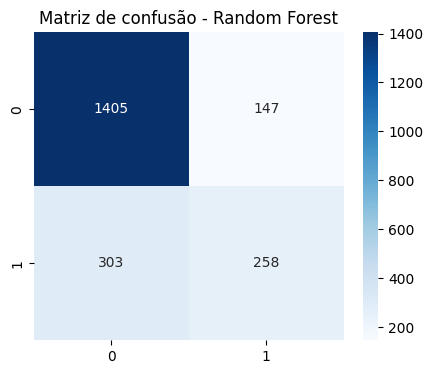

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)

pipe_rf = executar_modelo(model_rf, "Random Forest", X_train, y_train, X_test, y_test)

**Gradient Boosting**

Gradient Boosting
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1552
           1       0.64      0.49      0.55       561

    accuracy                           0.79      2113
   macro avg       0.73      0.69      0.71      2113
weighted avg       0.78      0.79      0.78      2113

ROC-AUC: 0.8400804206406086


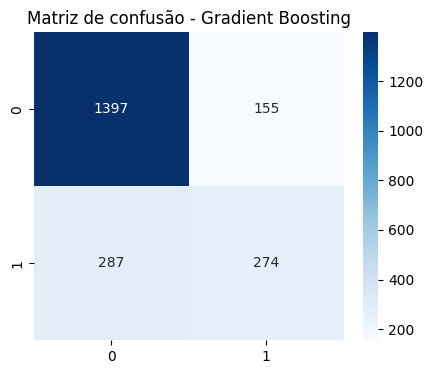

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier(random_state=42)

pipe_gb = executar_modelo(model_gb, "Gradient Boosting", X_train, y_train, X_test, y_test)

**Cross-Validation**

In [ ]:
from sklearn.model_selection import cross_val_score

modelos = [
    ('LogReg', LogisticRegression(class_weight='balanced', max_iter=1000)),
    ('RandomForest', RandomForestClassifier(class_weight='balanced')),
    ('GradBoost', GradientBoostingClassifier())
]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print("Cross-Validation (Média ROC-AUC)")
for nome, model in modelos:
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    print(f"{nome}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Cross-Validation (Média ROC-AUC)
LogReg: 0.8463 (+/- 0.0110)
RandomForest: 0.8297 (+/- 0.0118)
GradBoost: 0.8443 (+/- 0.0139)


# Avaliação dos modelos

In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

def get_metrics(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:,1]
    return{
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

metricas_rf = get_metrics(pipe_rf, X_test, y_test)
metricas_lr = get_metrics(pipe_lr, X_test, y_test)
metricas_gb = get_metrics(pipe_gb, X_test, y_test)

df_metrics = pd.DataFrame([metricas_rf, metricas_lr, metricas_gb], index=['Random Forest', 'Logistic Reg', 'Gradient Boosting'])
df_metrics

,Recall,Precision,F1-Score,ROC-AUC
Random Forest,0.459893,0.637037,0.534161,0.824379
Logistic Reg,0.793226,0.507412,0.618915,0.843972
Gradient Boosting,0.488414,0.638695,0.553535,0.840080


**Simulação de Impacto Financeiro**

In [ ]:
# Usando o pipe_lr (Regressão Logística) pois teve o melhor Recall 
# Criar DataFrame com os dados de Teste
df_impacto = X_test.copy()
df_impacto['Churn_Real'] = y_test
df_impacto['Churn_Predito'] = pipe_lr.predict(X_test)

df_impacto['MonthlyCharges'] = df.loc[X_test.index, 'MonthlyCharges']


alvo_campanha = df_impacto[df_impacto['Churn_Predito'] == 1]


qtd_alvo = len(alvo_campanha)
receita_em_risco = alvo_campanha['MonthlyCharges'].sum()

# Premissas da Simulação
taxa_retencao = 0.30      
custo_campanha = 5.00      
desconto_oferecido = 0.10  

clientes_salvos = int(qtd_alvo * taxa_retencao)


receita_salva_mensal = clientes_salvos * alvo_campanha['MonthlyCharges'].mean()


custo_total_campanha = qtd_alvo * custo_campanha


custo_descontos = receita_salva_mensal * desconto_oferecido


lucro_acao_mensal = receita_salva_mensal - custo_total_campanha - custo_descontos
lucro_acao_anual = lucro_acao_mensal * 12

print(f" SIMULAÇÃO DE NEGÓCIO (Baseado na Regressão Logística) ")
print(f"Público Alvo da Campanha: {qtd_alvo} clientes")
print(f"Receita Total em Risco detectada: $ {receita_em_risco:,.2f}")
print(f"------------------------------------------------")
print(f"Clientes Salvos estimados (30%): {clientes_salvos}")
print(f"Receita Retida (Bruta): $ {receita_salva_mensal:,.2f} / mês")
print(f"Custos (Operação + Descontos): -$ {custo_total_campanha + custo_descontos:,.2f}")
print(f"------------------------------------------------")
print(f"RETORNO LÍQUIDO MENSAL: $ {lucro_acao_mensal:,.2f}")
print(f"RETORNO LÍQUIDO ANUAL:  $ {lucro_acao_anual:,.2f}")

 SIMULAÇÃO DE NEGÓCIO (Baseado na Regressão Logística) 
Público Alvo da Campanha: 877 clientes
Receita Total em Risco detectada: $ 67,145.55
------------------------------------------------
Clientes Salvos estimados (30%): 263
Receita Retida (Bruta): $ 20,136.01 / mês
Custos (Operação + Descontos): -$ 6,398.60
------------------------------------------------
RETORNO LÍQUIDO MENSAL: $ 13,737.41
RETORNO LÍQUIDO ANUAL:  $ 164,848.89


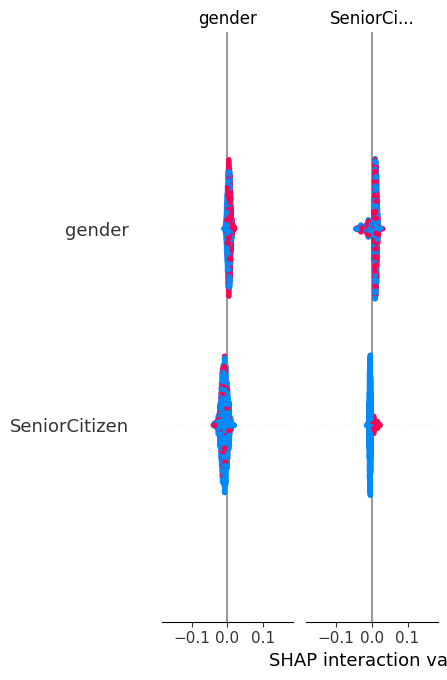

In [ ]:
import shap

explainer = shap.TreeExplainer(pipe_rf.named_steps['model'])
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)